In [61]:
import torch                          # import torch library
import torch.nn as nn                 # import nn module for creating layers, models and functions
import numpy as np                    # import numpy library
from torch.autograd import Variable   # variable from numpy to torch
import matplotlib.pyplot as plt       # import pyplot library

In [62]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # set GPU as processing device
print(device)

cuda:0


In [63]:
epochs = 1500 # number of training epochs
col_p  = 500  # number of collocation points

class NN(nn.Module):                           
    def __init__(self):                        
        super(NN, self).__init__()             # input layer, 2 inputs
        self.hidden_lay1 = nn.Linear(2,150)    # first hidden layer, 150 neurons
        self.hidden_lay2 = nn.Linear(150,150)  # second hidden layer, 150 neurons
        self.hidden_lay3 = nn.Linear(150,150)  # third hidden layer, 150 neurons
        self.hidden_lay4 = nn.Linear(150,150)  # fourth hidden layer, 150 neurons
        self.output_lay  = nn.Linear(150,1)    # output layer, 1 output
        
    def forward(self,x,y):
        inputs = torch.cat([x,y],axis=1)                     # combined two arrays of 1 columns each to one array of 2 columns
        lay1_out = torch.sigmoid(self.hidden_lay1(inputs))   # sigmoid activation function in hidden layer
        lay2_out = torch.sigmoid(self.hidden_lay2(lay1_out)) # sigmoid activation function in hidden layer
        lay3_out = torch.sigmoid(self.hidden_lay3(lay2_out)) # sigmoid activation function in hidden layer
        lay4_out = torch.sigmoid(self.hidden_lay4(lay3_out)) # sigmoid activation function in hidden layer
        output = self.output_lay(lay4_out)                   # for regression, no activation is used in output layer
        return output

In [64]:
### (2) Model
NN = NN()
NN = NN.to(device)                               # transfer net to GPU for processing
mse_cost_function = torch.nn.MSELoss()           # mean squared error as loss function
optimizer = torch.optim.Adam(NN.parameters())    # Adam optimizer for parameter updating

In [65]:
## PDE as loss function.
def f(x,y,NN):
    T = NN(x,y) # the dependent variable T is given by the network based on independent variables x and y
    ## Based on our f = d2T/dx2 + d2T/dy2, we need d2T/dx2 and d2T/dy2
    T_x  = torch.autograd.grad(T.sum(), x, create_graph=True)[0]  # dT/dx
    T_x2 = torch.autograd.grad(T_x.sum(),x,create_graph=True)[0]  # d2T/dx2
    T_y  = torch.autograd.grad(T.sum(), y, create_graph=True)[0]  # dT/dy
    T_y2 = torch.autograd.grad(T_x.sum(),y,create_graph=True)[0]  # d2T/dy2
    pde = T_x2 + T_y2                                             # Laplace Equation
    return pde

In [66]:
## Data from Boundary Conditions
## BC just gives us datapoints for training

#################################### 1. x=0, T(0,y)=0 ####################################
# BC tells us that for any y in range [0,5] and x=0, the value of T is 0
x_bc1 = np.zeros((col_p,1))  # Take say 500 random numbers of (x,y)
y_bc1 = np.random.uniform(low=0.0, high=5.0, size=(col_p,1))
T_bc1 = np.zeros((col_p,1))  # Compute T based on BC

#################################### 2. y=0, T(x,0)=0 ####################################
# BC tells us that for any x in range [0,4] and y=0, the value of T is 0
x_bc2 = np.random.uniform(low=0.0, high=4.0, size=(col_p,1))
y_bc2 = np.zeros((col_p,1))
T_bc2 = np.zeros((col_p,1))

################################ 3. x=4, T(4,y)=(4/5)*x*y ################################
# BC tells us that for any y in range [0,5] and x=4, the value of T is (4/5)*x*y
x_bc3 = 4*np.ones((col_p,1))
y_bc3 = np.random.uniform(low=0.0, high=5.0, size=(col_p,1))
T_bc3 = (4/5)*x_bc3*y_bc3

################################### 4. y=5, T(x,5)=x^2 ###################################
# BC tells us that for any x in range [0,4] and y=5, the value of T is x^2
x_bc4 = np.random.uniform(low=0.0, high=4.0, size=(col_p,1))
y_bc4 = 5*np.ones((col_p,1))
T_bc4 = x_bc4**2

In [67]:
### (3) Training / Fitting
L = []                    # Creating empty list for gathering loss values

previous_validation_loss = np.Inf

for epoch in range(epochs):
    optimizer.zero_grad() # to make the gradients zero
    
    # Loss based on boundary conditions
    # BC 1.
    pt_x_bc1 = Variable(torch.from_numpy(x_bc1).float(), requires_grad=False).to(device)
    pt_y_bc1 = Variable(torch.from_numpy(y_bc1).float(), requires_grad=False).to(device)
    pt_T_bc1 = Variable(torch.from_numpy(T_bc1).float(), requires_grad=False).to(device)
    
    NN_bc1_out = NN(pt_x_bc1, pt_y_bc1)              # output of T(x,y)
    mse_u1 = mse_cost_function(NN_bc1_out, pt_T_bc1)
    
    # BC 2.
    pt_x_bc2 = Variable(torch.from_numpy(x_bc2).float(), requires_grad=False).to(device)
    pt_y_bc2 = Variable(torch.from_numpy(y_bc2).float(), requires_grad=False).to(device)
    pt_T_bc2 = Variable(torch.from_numpy(T_bc2).float(), requires_grad=False).to(device)
    
    NN_bc2_out = NN(pt_x_bc2, pt_y_bc2)              # output of T(x,y)
    mse_u2 = mse_cost_function(NN_bc2_out, pt_T_bc2)
    
    # BC 3.
    pt_x_bc3 = Variable(torch.from_numpy(x_bc3).float(), requires_grad=False).to(device)
    pt_y_bc3 = Variable(torch.from_numpy(y_bc3).float(), requires_grad=False).to(device)
    pt_T_bc3 = Variable(torch.from_numpy(T_bc3).float(), requires_grad=False).to(device)
    
    NN_bc3_out = NN(pt_x_bc3, pt_y_bc3)              # output of T(x,y)
    mse_u3 = mse_cost_function(NN_bc3_out, pt_T_bc3)    
        
    # BC 4.
    pt_x_bc4 = Variable(torch.from_numpy(x_bc4).float(), requires_grad=False).to(device)
    pt_y_bc4 = Variable(torch.from_numpy(y_bc4).float(), requires_grad=False).to(device)
    pt_T_bc4 = Variable(torch.from_numpy(T_bc4).float(), requires_grad=False).to(device)
    
    NN_bc4_out = NN(pt_x_bc4, pt_y_bc4)              # output of T(x,y)
    mse_u4 = mse_cost_function(NN_bc4_out, pt_T_bc4)
    
    # Loss based on PDE
    x_col = np.random.uniform(low=0.0, high=4.0, size=(col_p,1))
    y_col = np.random.uniform(low=0.0, high=5.0, size=(col_p,1))
    all_zeros = np.zeros((col_p,1))
    
    pt_x_col = Variable(torch.from_numpy(x_col).float(), requires_grad=True).to(device)
    pt_y_col = Variable(torch.from_numpy(y_col).float(), requires_grad=True).to(device)
    pt_all_zeros = Variable(torch.from_numpy(all_zeros).float(), requires_grad=False).to(device)
    
    f_out = f(pt_x_col, pt_y_col, NN)                # output of f(x,t)
    mse_f = mse_cost_function(f_out, pt_all_zeros)
    
    # Combining the loss functions
    loss = mse_u1 +  mse_u2 +  mse_u3 +  mse_u4 + mse_f
    
    loss.backward() # This is for computing gradients using backward propagation
    optimizer.step() # This is equivalent to : theta_new = theta_old - alpha * derivative of J w.r.t theta
    
    loss_np = loss.data.cpu().numpy()
    L = np.append(L,loss_np)
    
    with torch.autograd.no_grad():
        if epoch % 10 == 0: print(epoch,"Traning Loss:",loss.data) # Print loss every 10 epochs

0 Traning Loss: tensor(130.2664, device='cuda:0')
10 Traning Loss: tensor(96.3277, device='cuda:0')
20 Traning Loss: tensor(91.9193, device='cuda:0')
30 Traning Loss: tensor(91.9727, device='cuda:0')
40 Traning Loss: tensor(90.5187, device='cuda:0')
50 Traning Loss: tensor(89.7521, device='cuda:0')
60 Traning Loss: tensor(88.2410, device='cuda:0')
70 Traning Loss: tensor(86.1122, device='cuda:0')
80 Traning Loss: tensor(82.8497, device='cuda:0')
90 Traning Loss: tensor(77.6491, device='cuda:0')
100 Traning Loss: tensor(69.0350, device='cuda:0')
110 Traning Loss: tensor(55.3265, device='cuda:0')
120 Traning Loss: tensor(37.9175, device='cuda:0')
130 Traning Loss: tensor(24.9448, device='cuda:0')
140 Traning Loss: tensor(17.0548, device='cuda:0')
150 Traning Loss: tensor(12.5273, device='cuda:0')
160 Traning Loss: tensor(9.4854, device='cuda:0')
170 Traning Loss: tensor(7.4075, device='cuda:0')
180 Traning Loss: tensor(6.1433, device='cuda:0')
190 Traning Loss: tensor(5.4596, device='cud

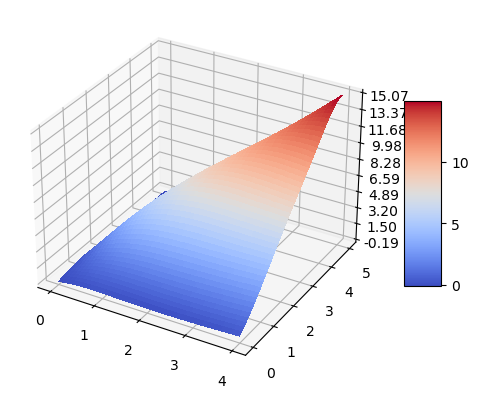

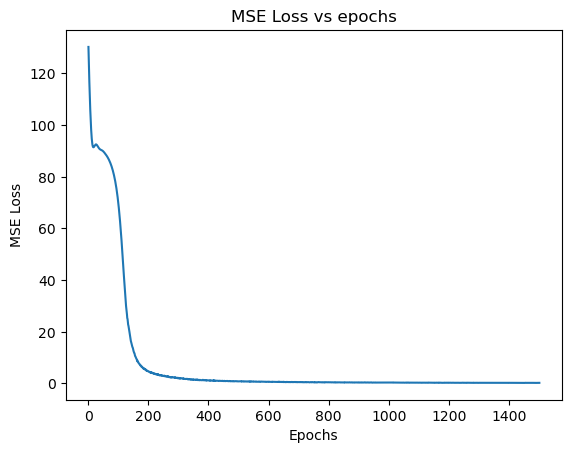

In [68]:
#### Plotting results ###

# Predicted surface
#from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = np.arange(0,4,0.01)
y = np.arange(0,5,0.01)
ms_x, ms_y = np.meshgrid(x, y)

# Just because meshgrid is used, we need to do the following adjustment
x = np.ravel(ms_x).reshape(-1,1)
y = np.ravel(ms_y).reshape(-1,1)

pt_x = Variable(torch.from_numpy(x).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y).float(), requires_grad=True).to(device)
pt_T = NN(pt_x,pt_y)
T    = pt_T.data.cpu().numpy()
ms_T = T.reshape(ms_x.shape)

surf = ax.plot_surface(ms_x,ms_y,ms_T, cmap=cm.coolwarm,linewidth=0, antialiased=False)
             
ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.02f'))

fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

# Loss graphics
ep = np.linspace(1,epochs,epochs)
plt.plot(ep,L)
plt.title('MSE Loss vs epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.show()